# Ingredient & Quantity Parser 
**Goal:** Extract ingredient tokens and quantities from free-text meal descriptions and map ingredient strings to best-matching USDA items using sentence embeddings + FAISS.

Path to dataset:
`C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\MM_Food_Cleaned_Final\MM_Food_Cleaned_Final.csv`


In [1]:
# Run this cell once to install packages (or run these in a terminal)
# NOTE: remove `!` if running in a terminal
!pip install pandas numpy regex tqdm sentence-transformers faiss-cpu scikit-learn unidecode

# Optional packages for advanced parsing
!pip install quantulum3
# Optional for huggingface training later
!pip install transformers datasets seqeval torch torchvision



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# CELL 3: Imports and path configuration
import os
import re
import json
import ast
import string
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
from tqdm import tqdm
from unidecode import unidecode

# Embedding + FAISS
from sentence_transformers import SentenceTransformer
import faiss

# Path configuration (update if needed)
DATA_DIR = r"C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data"
CSV_FILE = os.path.join(DATA_DIR, "MM_Food_Cleaned_Final.csv")
ART_DIR = os.path.join(DATA_DIR, "artifacts")
os.makedirs(ART_DIR, exist_ok=True)

print("DATA CSV:", CSV_FILE)
print("ARTIFACTS DIR:", ART_DIR)


DATA CSV: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\MM_Food_Cleaned_Final.csv
ARTIFACTS DIR: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts


In [39]:
# CELL 4: Load and inspect the MM dataset
df = pd.read_csv(CSV_FILE)
# If mm_id not present create one
if 'mm_id' not in df.columns:
    df = df.reset_index().rename(columns={'index':'mm_id'})

print("Loaded MM dataframe shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
# Sample some columns for quick sanity
for col in ['dish_name','ingredients','food_type','cooking_method']:
    if col in df.columns:
        print(f"\nSample from {col}:")
        display(df[col].dropna().sample(min(5, df[col].dropna().shape[0]), random_state=1))


Loaded MM dataframe shape: (10996, 18)
Columns: ['mm_id', 'dish_name', 'image_filepath', 'submission_date', 'food_type', 'food_type.1', 'cooking_method', 'ingredients', 'total_grams', 'is_duplicate_image', 'calories_kcal', 'fat_g', 'protein_g', 'carbohydrate_g', 'calories_kcal_per_100g', 'fat_g_per_100g', 'protein_g_per_100g', 'carbohydrate_g_per_100g']


,mm_id,dish_name,image_filepath,submission_date,food_type,food_type.1,cooking_method,ingredients,total_grams,is_duplicate_image,calories_kcal,fat_g,protein_g,carbohydrate_g,calories_kcal_per_100g,fat_g_per_100g,protein_g_per_100g,carbohydrate_g_per_100g
0,0,spicy crab,preprocessed_data\images_processed\0a0c19eb67a...,2025-07-05,Restaurant food,restaurant food,stir-fried,"['crab', 'sauce', 'spices', 'vegetables']",450.0,False,500,20.0,40.0,10.0,111.111111,4.444444,8.888889,2.222222
1,1,steamed snails,preprocessed_data\images_processed\066b7ba6197...,2025-07-01,Homemade food,homemade food,steamed,"['dipping sauce', 'garlic', 'herbs', 'snails']",350.0,False,200,5.0,30.0,10.0,57.142857,1.428571,8.571429,2.857143
2,2,chicken stirfry,preprocessed_data\images_processed\fecd381a783...,2025-07-18,Homemade food,homemade food,stir-frying,"['bell peppers', 'chicken', 'onions', 'soy sau...",450.0,False,450,20.0,30.0,25.0,100.000000,4.444444,6.666667,5.555556
3,3,grilled salmon,preprocessed_data\images_processed\01e3ca00199...,2025-07-19,Restaurant food,restaurant food,Grilling,"['butter sauce', 'herbs', 'salmon']",250.0,False,350,20.0,30.0,5.0,140.000000,8.000000,12.000000,2.000000
4,4,braised pork belly,preprocessed_data\images_processed\34256ac8f85...,2025-07-04,Restaurant food,restaurant food,Braised,"['Green Onion', 'Pork Belly', 'Rice', 'Soy Sau...",350.0,False,600,30.0,25.0,50.0,171.428571,8.571429,7.142857,14.285714



Sample from dish_name:


7691                       grilled fish
6294                            coconut
2982                         fried fish
5166    chicken and cauliflower stirfry
4209               roast meat with rice
Name: dish_name, dtype: object


Sample from ingredients:


7691                          ['fish', 'lemon', 'spices']
6294                                          ['Coconut']
2982                            ['fish', 'oil', 'spices']
5166    ['bell peppers', 'cauliflower', 'chicken', 'ga...
4209    ['rice', 'roast duck', 'roast pork', 'vegetabl...
Name: ingredients, dtype: object


Sample from food_type:


7691              Restaurant food
6294    Raw vegetables and fruits
2982                Homemade food
5166                Homemade food
4209              Restaurant food
Name: food_type, dtype: object


Sample from cooking_method:


10787    boiled and served
7794                Frying
4357                 Fried
7569                 Fried
2066           Stir-frying
Name: cooking_method, dtype: object

In [40]:
# CELL 5: Unit conversion table, fraction-first regex, word-number helper, and parsing functions

# Unit conversion table (heuristic approximations)
UNIT_TO_GRAMS = {
    'g': 1, 'gram': 1, 'grams': 1,
    'kg': 1000, 'kilogram': 1000,
    'mg': 0.001,
    'lb': 453.592, 'lbs': 453.592,
    'oz': 28.3495,
    'cup': 240, 'cups': 240,            # approximate; refine per-ingredient later
    'tablespoon': 15, 'tbsp': 15, 'tablespoons': 15,
    'teaspoon': 5, 'tsp': 5, 'teaspoons': 5,
    'slice': 30, 'slices': 30,
    'piece': 50, 'pieces': 50,
    'medium': 120, 'large': 200
}

# Fraction-first regex: fractions (1/2) matched BEFORE decimals/integers
QTY_REGEX = re.compile(
    r'(?P<number>\d+/\d+|\d+(?:[.,]\d+)?)\s*(?P<unit>grams?|g|kg|mg|lbs?|lb|oz|cup[s]?|tablespoon[s]?|tbsp|teaspoon[s]?|tsp|slice[s]?|pieces?|piece|medium|large)?',
    flags=re.IGNORECASE
)

# small map for common word numbers -> digits
_word_num_map = {
    'a': '1', 'an': '1', 'one': '1', 'two': '2', 'three': '3', 'four': '4', 'five': '5',
    'six': '6', 'seven': '7', 'eight': '8', 'nine': '9', 'ten': '10',
    'half': '1/2', 'quarter': '1/4'
}

def _words_to_digits(text):
    """Replace very common word numbers with digits (simple heuristic)."""
    if not isinstance(text, str):
        return text
    tokens = text.split()
    out = []
    for t in tokens:
        tl = t.lower().strip(",.")
        if tl in _word_num_map:
            out.append(_word_num_map[tl])
        else:
            out.append(t)
    return " ".join(out)

def parse_quantity_unit(text):
    """
    Extract quantity (float) and unit (str or None) from a text phrase.
    Handles fractions (1/2), decimals, integers, and simple word-numbers (one, half).
    """
    if not isinstance(text, str):
        return None, None
    text = text.strip()
    # convert simple word numbers first
    text_for_regex = _words_to_digits(text)
    m = QTY_REGEX.search(text_for_regex)
    if not m:
        return None, None
    num = m.group('number')
    qty = None
    try:
        if '/' in num:
            numerator, denominator = num.split('/')
            qty = float(numerator) / float(denominator)
        else:
            qty = float(num.replace(',', '.'))
    except Exception:
        qty = None
    unit = m.group('unit')
    if unit:
        unit = unit.lower().strip().rstrip('.')
    return qty, unit

def qty_unit_to_grams(qty, unit, ingredient_hint=None):
    """
    Convert quantity+unit to grams using UNIT_TO_GRAMS fallback and heuristics.
    If unit is None pick heuristic: small qty -> pieces, large qty -> grams.
    """
    if qty is None:
        return None
    if unit is None:
        try:
            if float(qty) <= 20:
                return float(qty) * UNIT_TO_GRAMS.get('piece', 50)
            else:
                return float(qty)  # assume grams
        except Exception:
            return float(qty)
    unit_norm = unit.lower().rstrip('s')
    if unit_norm in ['tbsp']:
        unit_norm = 'tablespoon'
    if unit_norm in ['tsp']:
        unit_norm = 'teaspoon'
    if unit_norm in UNIT_TO_GRAMS:
        return float(qty) * UNIT_TO_GRAMS[unit_norm]
    if unit_norm in ['cup']:
        return float(qty) * UNIT_TO_GRAMS.get('cup', 240)
    return float(qty)


In [41]:
# CELL 6: Test the parse functions with several examples
examples = [
    "2 cups oatmeal", "1.5 tbsp olive oil", "100 g chicken", "one cup rice",
    "1/2 tsp salt", "3 slices bread", "2 medium apples", "250grams yogurt",
    "12 oz salmon", "0.75 kg potatoes", "2.5lbs steak"
]

for ex in examples:
    q,u = parse_quantity_unit(ex)
    grams = qty_unit_to_grams(q,u)
    print(f"Input: {ex:<25} -> qty={q}, unit={u}, approx_grams={grams}")


Input: 2 cups oatmeal            -> qty=2.0, unit=cups, approx_grams=480.0
Input: 1.5 tbsp olive oil        -> qty=1.5, unit=tbsp, approx_grams=22.5
Input: 100 g chicken             -> qty=100.0, unit=g, approx_grams=100.0
Input: one cup rice              -> qty=1.0, unit=cup, approx_grams=240.0
Input: 1/2 tsp salt              -> qty=0.5, unit=tsp, approx_grams=2.5
Input: 3 slices bread            -> qty=3.0, unit=slices, approx_grams=90.0
Input: 2 medium apples           -> qty=2.0, unit=medium, approx_grams=240.0
Input: 250grams yogurt           -> qty=250.0, unit=grams, approx_grams=250.0
Input: 12 oz salmon              -> qty=12.0, unit=oz, approx_grams=340.19399999999996
Input: 0.75 kg potatoes          -> qty=0.75, unit=kg, approx_grams=750.0
Input: 2.5lbs steak              -> qty=2.5, unit=lbs, approx_grams=1133.98


In [42]:
# CELL 7: Split free-text meal descriptions into ingredient phrases
SPLIT_PAT = re.compile(r'\s*(?:\+|,|;| and | & | with )\s*', flags=re.IGNORECASE)

def split_to_ingredients(meal_text):
    if not isinstance(meal_text, str):
        return []
    parts = [p.strip() for p in SPLIT_PAT.split(meal_text) if p.strip()]
    return parts

# Test splitting
meal_examples = [
    "2 cups oatmeal + 1 banana",
    "Grilled chicken with 1 cup rice and 1/2 cup salad",
    "2 slices bread, 1 tbsp butter",
    "Masala dosa with potato filling"
]
for m in meal_examples:
    print("\nMEAL:", m)
    for p in split_to_ingredients(m):
        q,u = parse_quantity_unit(p)
        print("  ->", p, "| qty:", q, "| unit:", u)



MEAL: 2 cups oatmeal + 1 banana
  -> 2 cups oatmeal | qty: 2.0 | unit: cups
  -> 1 banana | qty: 1.0 | unit: None

MEAL: Grilled chicken with 1 cup rice and 1/2 cup salad
  -> Grilled chicken | qty: None | unit: None
  -> 1 cup rice | qty: 1.0 | unit: cup
  -> 1/2 cup salad | qty: 0.5 | unit: cup

MEAL: 2 slices bread, 1 tbsp butter
  -> 2 slices bread | qty: 2.0 | unit: slices
  -> 1 tbsp butter | qty: 1.0 | unit: tbsp

MEAL: Masala dosa with potato filling
  -> Masala dosa | qty: None | unit: None
  -> potato filling | qty: None | unit: None


In [43]:
# CELL 8: Build cleaned candidate strings from the MM dataset and save mapping
candidate_set = {}

def add_candidate(key, text):
    if not isinstance(text, str) or text.strip() == '':
        return
    # normalized key for dedupe
    tkey = unidecode(text.strip().lower())
    if tkey not in candidate_set:
        candidate_set[tkey] = {"mm_ids": [int(key)], "text": text.strip()}
    else:
        if int(key) not in candidate_set[tkey]["mm_ids"]:
            candidate_set[tkey]["mm_ids"].append(int(key))

def normalize_text_for_candidate(s):
    """
    Safely normalize a string to either a cleaned string or try parsing as a stringified list.
    Returns (normalized_string_or_None, items_list_or_None)
    """
    if not isinstance(s, str):
        return None, None
    s2 = s.strip()
    # If looks like a list, try literal_eval
    if s2.startswith('[') and s2.endswith(']'):
        try:
            items = ast.literal_eval(s2)
            if isinstance(items, (list, tuple)):
                return None, items
        except Exception:
            pass
    # strip quotes/brackets/punctuation
    s2 = s2.strip(" \t\n\r'\"[](){}")
    s2 = s2.strip(string.punctuation)
    s2 = " ".join(s2.split())
    if s2 == "":
        return None, None
    return s2, None

# Iterate rows and add candidates (dish_name, ingredient items, composed fallback)
for idx, row in df.iterrows():
    mmid = int(row['mm_id'])
    # dish_name
    if isinstance(row.get('dish_name'), str) and row['dish_name'].strip():
        norm, items = normalize_text_for_candidate(row['dish_name'])
        if norm:
            add_candidate(mmid, norm)
    # ingredients column might be stringified list or single item
    ing = row.get('ingredients')
    if isinstance(ing, str) and ing.strip():
        norm, items = normalize_text_for_candidate(ing)
        if items:
            for p in items:
                if isinstance(p, str) and p.strip():
                    add_candidate(mmid, p.strip())
        elif norm:
            add_candidate(mmid, norm)
    # composed fallback fields
    composed = []
    for c in ['dish_name','food_type','cooking_method']:
        val = row.get(c)
        if isinstance(val, str) and val.strip():
            composed.append(val.strip())
    if composed:
        add_candidate(mmid, " - ".join(composed))

# Finalize candidate_texts
candidate_texts = list(candidate_set.keys())
print("Built", len(candidate_texts), "clean candidate strings from MM dataset (sample 20):")
for t in candidate_texts[:20]:
    print("-", t)

# Save mapping artifact
with open(os.path.join(ART_DIR, "mm_candidate_map.json"), "w", encoding="utf8") as f:
    json.dump(candidate_set, f, ensure_ascii=False, indent=2)
print("Saved candidate mapping:", os.path.join(ART_DIR, "mm_candidate_map.json"))


Built 10858 clean candidate strings from MM dataset (sample 20):
- spicy crab
- crab
- sauce
- spices
- vegetables
- spicy crab - restaurant food - stir-fried
- steamed snails
- dipping sauce
- garlic
- herbs
- snails
- steamed snails - homemade food - steamed
- chicken stirfry
- bell peppers
- chicken
- onions
- soy sauce
- chicken stirfry - homemade food - stir-frying
- grilled salmon
- butter sauce
Saved candidate mapping: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts\mm_candidate_map.json


In [44]:
# CELL 9: Build embeddings for candidate_texts and FAISS index (use a small, fast model)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"   # small & fast
print("Loading embedder:", EMBEDDING_MODEL)
embedder = SentenceTransformer(EMBEDDING_MODEL)

print("Encoding", len(candidate_texts), "candidate strings...")
candidate_embeddings = embedder.encode(candidate_texts, show_progress_bar=True, convert_to_numpy=True)
print("Embeddings shape:", candidate_embeddings.shape, "dtype:", candidate_embeddings.dtype)

# Normalize and build FAISS index (inner product on normalized vectors -> cosine similarity)
faiss.normalize_L2(candidate_embeddings)
dim = candidate_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(candidate_embeddings)
print("Built FAISS index with", index.ntotal, "vectors.")

# Save index & artifacts
faiss_index_path = os.path.join(ART_DIR, "mm_candidates_faiss.index")
faiss.write_index(index, faiss_index_path)
np.save(os.path.join(ART_DIR, "mm_candidate_embeddings.npy"), candidate_embeddings)
with open(os.path.join(ART_DIR, "mm_candidate_texts.json"), "w", encoding="utf8") as f:
    json.dump(candidate_texts, f, ensure_ascii=False)
print("Saved FAISS index and candidate artifacts to:", ART_DIR)


Loading embedder: all-MiniLM-L6-v2
Encoding 10858 candidate strings...


Batches:   0%|          | 0/340 [00:00<?, ?it/s]

Embeddings shape: (10858, 384) dtype: float32
Built FAISS index with 10858 vectors.
Saved FAISS index and candidate artifacts to: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts


In [45]:
# CELL 10: map_ingredient_to_mm (returns top-k candidate entries with mm_ids list)
def map_ingredient_to_mm(ingredient_phrase, top_k=5):
    """
    Map ingredient phrase -> top-k candidate strings.
    Returns list of dicts: { 'mm_ids': [...], 'text': ..., 'score': float }
    """
    if not ingredient_phrase or not isinstance(ingredient_phrase, str):
        return []
    q = unidecode(ingredient_phrase.lower())
    q_emb = embedder.encode([q], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        cand_text = candidate_texts[idx]
        cand_info = candidate_set.get(cand_text, {})
        results.append({
            "mm_ids": cand_info.get('mm_ids', []),
            "text": cand_info.get('text', cand_text),
            "score": float(score)
        })
    return results

# Quick manual tests
tests = ["oatmeal", "olive oil", "plain yogurt", "chicken breast", "2 cups rice"]
for t in tests:
    print("\nInput:", t)
    for r in map_ingredient_to_mm(t, top_k=5):
        print(" -> mm_ids:", r['mm_ids'][:6], "text:", r['text'], "sim:", round(r['score'],4))



Input: oatmeal
 -> mm_ids: [229, 568, 3304, 6009, 6456, 8345] text: oatmeal sim: 1.0
 -> mm_ids: [3643] text: instant oatmeal sim: 0.8677
 -> mm_ids: [568, 2089, 2115, 3643, 3991, 4152] text: oats sim: 0.821
 -> mm_ids: [2089] text: oatmeal bars sim: 0.8065
 -> mm_ids: [229] text: oatmeal with kiwi sim: 0.7601

Input: olive oil
 -> mm_ids: [241, 393, 396, 408, 441, 783] text: olive oil sim: 1.0
 -> mm_ids: [80, 333, 621, 1038, 1218, 1501] text: olives sim: 0.763
 -> mm_ids: [5472, 6241] text: olive sim: 0.7606
 -> mm_ids: [294, 462, 651, 652, 662, 1818] text: vegetable oil sim: 0.7437
 -> mm_ids: [8, 31, 55, 64, 89, 93] text: oil sim: 0.6637

Input: plain yogurt
 -> mm_ids: [172, 249, 753, 943, 1259, 1297] text: yogurt sim: 0.8821
 -> mm_ids: [753] text: flavored yogurt sim: 0.8493
 -> mm_ids: [1259] text: fruit yogurt sim: 0.8385
 -> mm_ids: [8015] text: strawberry yogurt sim: 0.8316
 -> mm_ids: [2941, 4407] text: yogurt - Homemade food sim: 0.829

Input: chicken breast
 -> mm_ids: [

In [46]:
# CELL 11: Full pipeline: parse a meal into parts, find qty/grams, and map each part to MM candidates
def parse_and_map_meal_mm(meal_text, top_k=5):
    parts = split_to_ingredients(meal_text)
    parsed = []
    for p in parts:
        qty, unit = parse_quantity_unit(p)
        grams = qty_unit_to_grams(qty, unit)
        # remove matched qty/unit substring to get clean phrase
        p_clean = QTY_REGEX.sub('', p).strip()
        matches = map_ingredient_to_mm(p_clean, top_k=top_k)
        parsed.append({
            "original": p,
            "clean": p_clean,
            "qty": qty,
            "unit": unit,
            "approx_grams": grams,
            "matches": matches
        })
    return parsed

# Example
meal = "2 cups oatmeal + 1 banana + 1.5 tbsp olive oil"
result = parse_and_map_meal_mm(meal, top_k=5)
import pprint
pprint.pprint(result, width=140)


[{'approx_grams': 480.0,
  'clean': 'oatmeal',
  'matches': [{'mm_ids': [229, 568, 3304, 6009, 6456, 8345, 8348, 9037, 10599], 'score': 1.0, 'text': 'oatmeal'},
              {'mm_ids': [3643], 'score': 0.8676580190658569, 'text': 'instant oatmeal'},
              {'mm_ids': [568, 2089, 2115, 3643, 3991, 4152, 4831, 6009, 6276, 6597, 8348, 8532, 8692, 9037],
               'score': 0.8210079669952393,
               'text': 'oats'},
              {'mm_ids': [2089], 'score': 0.806475043296814, 'text': 'oatmeal bars'},
              {'mm_ids': [229], 'score': 0.7600522041320801, 'text': 'oatmeal with kiwi'}],
  'original': '2 cups oatmeal',
  'qty': 2.0,
  'unit': 'cups'},
 {'approx_grams': 50.0,
  'clean': 'banana',
  'matches': [{'mm_ids': [107,
                          117,
                          121,
                          453,
                          641,
                          1297,
                          1451,
                          1700,
                        

In [47]:
# NEW CELL 12: Sanitize nutrient fields (coerce numeric, remove infs, compute per-100g where possible)
import math
absolute_nutr_cols = ['calories_kcal','fat_g','protein_g','carbohydrate_g']
per100_cols = ['calories_kcal_per_100g','fat_g_per_100g','protein_g_per_100g','carbohydrate_g_per_100g']

# Convert to numeric, coerce errors to NaN
for col in absolute_nutr_cols + per100_cols + ['total_grams']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace infinities with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Compute missing per-100g using total_grams if possible
for abs_col, per_col in zip(absolute_nutr_cols, per100_cols):
    if per_col in df.columns and abs_col in df.columns and 'total_grams' in df.columns:
        mask = df[per_col].isna() & df[abs_col].notna() & df['total_grams'].notna() & (df['total_grams'] > 0)
        if mask.any():
            df.loc[mask, per_col] = (df.loc[mask, abs_col] / df.loc[mask, 'total_grams']) * 100.0

# Final cleanup
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Sanitization complete. Non-null counts for per-100g columns:")
for c in per100_cols:
    if c in df.columns:
        print(f"{c}: {df[c].notna().sum()} / {len(df)}")


Sanitization complete. Non-null counts for per-100g columns:
calories_kcal_per_100g: 10887 / 10996
fat_g_per_100g: 10887 / 10996
protein_g_per_100g: 10887 / 10996
carbohydrate_g_per_100g: 10887 / 10996


In [48]:
# NEW CELL 13: Functions to aggregate per-100g across mm_ids, choose representative mmid, and compute scaled nutrients

def aggregate_nutrients_for_mmids(mm_ids, cols_per100=per100_cols, top_k=None):
    """Aggregate per-100g nutrient columns for provided mm_ids (mean ignoring NaN)."""
    if not mm_ids:
        return {c: float('nan') for c in cols_per100}
    if top_k is not None:
        mm_ids = mm_ids[:top_k]
    sub = df[df['mm_id'].isin(mm_ids)]
    agg = {}
    for col in cols_per100:
        if col in sub.columns:
            vals = pd.to_numeric(sub[col], errors='coerce').dropna()
            agg[col] = float(vals.mean()) if len(vals) > 0 else float('nan')
        else:
            agg[col] = float('nan')
    return agg

def choose_representative_mmid(mm_ids):
    """Choose a representative mm_id (most frequent among list or first if unique)."""
    if not mm_ids:
        return None
    c = Counter(mm_ids)
    rep = sorted(c.items(), key=lambda x: (-x[1], x[0]))[0][0]
    return int(rep)

def compute_scaled_nutrients_from_per100(agg_per100, grams):
    """Compute absolute nutrient amounts from per-100g aggregated profile."""
    res = {}
    if grams is None or (isinstance(grams, float) and math.isnan(grams)):
        for perc in agg_per100.keys():
            res[perc.replace('_per_100g','')] = float('nan')
        return res
    for per_col, val in agg_per100.items():
        nutrient = per_col.replace('_per_100g','')
        if val is None or (isinstance(val, float) and math.isnan(val)):
            res[nutrient] = float('nan')
        else:
            res[nutrient] = float(val) * (float(grams) / 100.0)
    return res

def map_and_compute(ingredient_phrase, approx_grams=None, top_k_candidates=5, aggregate_topk=5):
    """
    Map phrase -> matches, aggregate per-100g across top-N mm_ids for each match, compute scaled nutrients.
    Returns enriched match list with aggregated & scaled nutrient info and representative mmid.
    """
    raw_matches = map_ingredient_to_mm(ingredient_phrase, top_k=top_k_candidates)
    enriched = []
    for m in raw_matches:
        mm_ids = m.get('mm_ids', [])
        agg_per100 = aggregate_nutrients_for_mmids(mm_ids, cols_per100=per100_cols, top_k=aggregate_topk)
        scaled = compute_scaled_nutrients_from_per100(agg_per100, approx_grams)
        rep = choose_representative_mmid(mm_ids)
        enriched.append({
            "text": m.get('text'),
            "score": m.get('score'),
            "mm_ids": mm_ids,
            "representative_mmid": rep,
            "aggregated_per100g": agg_per100,
            "scaled_nutrients_for_grams": scaled
        })
    return enriched


In [49]:
# NEW CELL 14: Example: compute scaled nutrients for a meal and show final table + totals
meal = "2 cups oatmeal + 1 banana + 1.5 tbsp olive oil"
parsed = parse_and_map_meal_mm(meal, top_k=5)

print("Parsed components:")
for p in parsed:
    print("-", p['original'], "| clean:", p['clean'], "| approx_grams:", p['approx_grams'])

print("\nMapped & computed nutrient estimates (top match shown):")
final_rows = []
for p in parsed:
    grams = p.get('approx_grams')
    clean = p.get('clean')
    mapped = map_and_compute(clean, approx_grams=grams, top_k_candidates=5, aggregate_topk=5)
    # take top mapped entry (best sim)
    top = mapped[0] if mapped else None
    row = {
        "original": p['original'],
        "clean": clean,
        "approx_grams": grams,
        "rep_mmid": top['representative_mmid'] if top else None
    }
    if top:
        for k,v in top['scaled_nutrients_for_grams'].items():
            row[k] = v
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
display(final_df)

# Sum numeric nutrient columns to get meal-level totals (ignoring NaNs)
nutrient_cols = [c for c in final_df.columns if c not in ['original','clean','approx_grams','rep_mmid']]
if nutrient_cols:
    totals = final_df[nutrient_cols].apply(pd.to_numeric, errors='coerce').sum(skipna=True)
    print("\nEstimated meal totals:")
    print(totals)
else:
    print("No nutrient columns available to sum.")


Parsed components:
- 2 cups oatmeal | clean: oatmeal | approx_grams: 480.0
- 1 banana | clean: banana | approx_grams: 50.0
- 1.5 tbsp olive oil | clean: olive oil | approx_grams: 22.5

Mapped & computed nutrient estimates (top match shown):


,original,clean,approx_grams,rep_mmid,calories_kcal,fat_g,protein_g,carbohydrate_g
0,2 cups oatmeal,oatmeal,480.0,229,465.018182,11.389091,15.287273,77.774545
1,1 banana,banana,50.0,107,49.539474,0.989474,0.610526,10.355263
2,1.5 tbsp olive oil,olive oil,22.5,241,31.914747,1.353629,1.703882,3.216359



Estimated meal totals:
calories_kcal     546.472402
fat_g              13.732194
protein_g          17.601682
carbohydrate_g     91.346168
dtype: float64


In [50]:
# CELL 15: Create or load a small eval CSV for mapping evaluation (fill ground_truth_mmid manually)
EVAL_PATH = os.path.join(DATA_DIR, "artifact_eval_mapping_mm.csv")
if os.path.exists(EVAL_PATH):
    eval_df = pd.read_csv(EVAL_PATH)
    print("Loaded eval set with", len(eval_df), "rows")
else:
    sample_phrases = ["oatmeal","olive oil","plain yogurt","chicken breast","white rice","banana","french fries"]
    eval_df = pd.DataFrame({"phrase": sample_phrases, "ground_truth_mmid": [""]*len(sample_phrases)})
    eval_df.to_csv(EVAL_PATH, index=False)
    print("Created template eval file at:", EVAL_PATH)
display(eval_df.head())

def evaluate_mapping_mm(eval_df, top_k=5):
    correct_top1 = 0
    correct_topk = 0
    n = 0
    for _, row in eval_df.iterrows():
        phrase = row['phrase']
        gt = str(row['ground_truth_mmid']).strip()
        if gt == "":
            continue
        n += 1
        matches = [m['representative_mmid'] for m in map_and_compute(phrase, approx_grams=None, top_k_candidates=top_k, aggregate_topk=top_k)]
        if len(matches) == 0:
            continue
        if str(matches[0]) == gt:
            correct_top1 += 1
        if gt in [str(x) for x in matches]:
            correct_topk += 1
    if n == 0:
        print("No ground truth labels present in eval file. Fill ground_truth_mmid column and rerun.")
        return
    print("Eval size:", n)
    print("Top-1 accuracy:", correct_top1 / n)
    print(f"Top-{top_k} accuracy:", correct_topk / n)

# To run evaluation after you label the CSV: uncomment and run
# evaluate_mapping_mm(pd.read_csv(EVAL_PATH), top_k=5)


Created template eval file at: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifact_eval_mapping_mm.csv


,phrase,ground_truth_mmid
0,oatmeal,
1,olive oil,
2,plain yogurt,
3,chicken breast,
4,white rice,


In [51]:
# CELL 16: Save a small config for quick load in Streamlit or other app
config_mm = {
    "embedding_model": EMBEDDING_MODEL,
    "faiss_index": faiss_index_path,
    "candidate_texts_file": os.path.join(ART_DIR, "mm_candidate_texts.json"),
    "candidate_map_file": os.path.join(ART_DIR, "mm_candidate_map.json")
}
with open(os.path.join(ART_DIR, "ingredient_parser_mm_config.json"), "w", encoding="utf8") as f:
    json.dump(config_mm, f, indent=2)
print("Saved parser config:", os.path.join(ART_DIR, "ingredient_parser_mm_config.json"))


Saved parser config: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts\ingredient_parser_mm_config.json


In [52]:
# CELL 17: OPTIONAL - placeholder for DistilBERT NER token-level training
print("Optional NER training cell placeholder. Enable only when you have token-labeled data.")
# (Add full training pipeline when you have labeled tokens: use HuggingFace datasets, tokenizers, Trainer)


Optional NER training cell placeholder. Enable only when you have token-labeled data.


# Summary — Updated Ingredient Parser / Mapping (MM-only)
We replaced USDA with your own MM dataset. Implemented:
- Candidate creation from `dish_name`, `ingredients`, and other columns.
- Sentence-transformer embeddings + FAISS index for MM candidate matching.
- Mapping function `map_ingredient_to_mm()` that returns mm_id + nutrient preview.
- Full parse-and-map pipeline `parse_and_map_meal_mm()` to produce parsed ingredient parts and top matched MM rows.
- Evaluation template `artifact_eval_mapping_mm.csv` for manual labeling and measurement.
- Saved artifacts and parser config for Streamlit.

**Next recommended step (Feature 2 — Nutrition Aggregator):**
1. Use `parse_and_map_meal_mm()` outputs to fetch nutrient per 100g for the matched `mm_id` from `df`.
2. Scale nutrients by `approx_grams` (gram/100 * nutrient_per_100g).
3. Sum across ingredients to produce per-meal totals.
4. Visualize example meal nutrient breakdowns and store results (CSV) for downstream apps.

If you want, I’ll now provide the **Feature 2 cells** that implement aggregation, scaling, visualization and validation examples (per-meal totals, bar charts of macros, and saving per-meal results). Shall I proceed with Feature 2 now?


# Feature 2 — Nutrition Aggregator
**Goal:** take parsed ingredient parts + approx_grams (from Feature 1) and compute per-ingredient and per-meal nutrient totals. Provide %RDA coverage, daily aggregation utilities, basic evaluation, and save outputs for Streamlit.


In [53]:
# CELL 2: Imports and path config
import os, json, math
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# Paths (adjust if needed)
DATA_DIR = r"C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data"
CSV_FILE = os.path.join(DATA_DIR, "MM_Food_Cleaned_Final.csv")
ART_DIR = os.path.join(DATA_DIR, "artifacts")
os.makedirs(ART_DIR, exist_ok=True)

print("DATA CSV:", CSV_FILE)
print("ARTIFACTS DIR:", ART_DIR)


DATA CSV: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\MM_Food_Cleaned_Final.csv
ARTIFACTS DIR: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts


In [54]:
# CELL 3: Load main dataframe and artifacts created earlier
df = pd.read_csv(CSV_FILE)
# ensure mm_id exists
if 'mm_id' not in df.columns:
    df = df.reset_index().rename(columns={'index':'mm_id'})

# load candidate map and candidate_texts if present
candidate_map_path = os.path.join(ART_DIR, "mm_candidate_map.json")
candidate_texts_path = os.path.join(ART_DIR, "mm_candidate_texts.json")
emb_path = os.path.join(ART_DIR, "mm_candidate_embeddings.npy")
faiss_index_path = os.path.join(ART_DIR, "mm_candidates_faiss.index")
print("Loaded df shape:", df.shape)
print("Candidate map exists:", os.path.exists(candidate_map_path))
print("FAISS index exists:", os.path.exists(faiss_index_path))

# load candidate_set if available (used for mapping)
if os.path.exists(candidate_map_path):
    with open(candidate_map_path, "r", encoding="utf8") as f:
        candidate_set = json.load(f)
else:
    candidate_set = {}

# load candidate_texts list if available
if os.path.exists(candidate_texts_path):
    with open(candidate_texts_path, "r", encoding="utf8") as f:
        candidate_texts = json.load(f)
else:
    candidate_texts = list(candidate_set.keys())

# print example candidate
print("Sample candidate_texts (first 10):", candidate_texts[:10])


Loaded df shape: (10996, 18)
Candidate map exists: True
FAISS index exists: True
Sample candidate_texts (first 10): ['spicy crab', 'crab', 'sauce', 'spices', 'vegetables', 'spicy crab - restaurant food - stir-fried', 'steamed snails', 'dipping sauce', 'garlic', 'herbs']


In [55]:
# CELL 4: Define nutrient columns used and helper functions for safe numeric ops
ABS_NUTR = ['calories_kcal','fat_g','protein_g','carbohydrate_g']
PER100 = ['calories_kcal_per_100g','fat_g_per_100g','protein_g_per_100g','carbohydrate_g_per_100g']

# ensure numeric types
for c in ABS_NUTR + PER100 + ['total_grams']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# small helper: safe numeric mean ignoring NaN
def safe_mean(lst):
    arr = np.array([x for x in lst if x is not None and not (isinstance(x,float) and np.isnan(x))])
    return float(arr.mean()) if len(arr) > 0 else float('nan')

def per100_to_amount(per100_val, grams):
    """Convert per-100g value to absolute amount for given grams."""
    try:
        if per100_val is None or (isinstance(per100_val, float) and np.isnan(per100_val)) or grams is None or np.isnan(grams):
            return float('nan')
        return float(per100_val) * (float(grams) / 100.0)
    except Exception:
        return float('nan')


In [56]:
# CELL 5: Functions to choose representative mm_id and aggregate per-100g across mm_ids (top-K)
from collections import Counter

def choose_representative_mmid_score(mm_ids, prefer_min_total_grams=20):
    """
    Choose representative mm_id from a list:
    - Prefer mm_id(s) whose total_grams >= prefer_min_total_grams and has non-null per100 values
    - If multiple, choose the one with median calories_kcal_per_100g closests to group mean.
    - Fallback: most common mm_id or first element.
    """
    if not mm_ids:
        return None
    # filter df rows
    sub = df[df['mm_id'].isin(mm_ids)].copy()
    # prefer rows with reasonable total_grams and per100 available
    if 'total_grams' in sub.columns:
        sub_pref = sub[(sub['total_grams'] >= prefer_min_total_grams)]
        # also require at least one per100 col non-null
        sub_pref = sub_pref.dropna(subset=PER100, how='all')
        if not sub_pref.empty:
            # choose the row whose calories_kcal_per_100g is closest to median
            if 'calories_kcal_per_100g' in sub_pref.columns:
                median = sub_pref['calories_kcal_per_100g'].median()
                sub_pref['dist'] = (sub_pref['calories_kcal_per_100g'] - median).abs()
                rep = int(sub_pref.sort_values(['dist','mm_id']).iloc[0]['mm_id'])
                return rep
            else:
                return int(sub_pref.sort_values('mm_id').iloc[0]['mm_id'])
    # fallback: most common mm_id in list
    c = Counter(mm_ids)
    rep = sorted(c.items(), key=lambda x: (-x[1], x[0]))[0][0]
    return int(rep)

def aggregate_per100_for_mmids(mm_ids, top_k=None):
    """Aggregate per-100g columns by taking mean across the provided mm_ids (optionally top_k)."""
    if not mm_ids:
        return {col: float('nan') for col in PER100}
    if top_k is not None:
        mm_ids = mm_ids[:top_k]
    sub = df[df['mm_id'].isin(mm_ids)]
    agg = {}
    for col in PER100:
        if col in sub.columns:
            vals = pd.to_numeric(sub[col], errors='coerce').dropna()
            agg[col] = float(vals.mean()) if len(vals)>0 else float('nan')
        else:
            agg[col] = float('nan')
    return agg


In [57]:
# CELL 6: Given a parsed ingredient entry (clean text + approx_grams) compute nutrient amounts
def compute_ingredient_nutrients(clean_text, approx_grams, top_k_candidates=5, aggregate_topk=5):
    """
    Input:
      clean_text: normalized ingredient text (string)
      approx_grams: float grams estimated from parser
    Returns:
      dict with: chosen_rep_mmid, agg_per100 (dict), scaled_amounts (dict for ABS_NUTR)
    """
    matches = map_ingredient_to_mm(clean_text, top_k=top_k_candidates)  # uses FAISS mapping from Feature1
    if not matches:
        return {"error":"no match", "scaled":{k:float('nan') for k in ABS_NUTR}}
    # For each match (candidate), we have mm_ids list; choose candidate[0] as best semantically
    top_match = matches[0]
    mm_ids = top_match.get('mm_ids', [])
    # compute aggregated per-100g across mm_ids but restrict to aggregate_topk to avoid noisy huge lists
    agg_per100 = aggregate_per100_for_mmids(mm_ids, top_k=aggregate_topk)
    # choose representative mmid for fallback/reference
    rep = choose_representative_mmid_score(mm_ids)
    # Now compute scaled absolute amounts for ABS_NUTR from aggregated per100
    scaled = {}
    for per_col, abs_col in zip(PER100, ABS_NUTR):
        per_val = agg_per100.get(per_col, float('nan'))
        scaled_val = per100_to_amount(per_val, approx_grams)
        scaled[abs_col] = scaled_val
    return {
        "candidate_text": top_match.get('text'),
        "score": top_match.get('score'),
        "mm_ids": mm_ids,
        "representative_mmid": rep,
        "aggregated_per100g": agg_per100,
        "scaled_absolute": scaled
    }


In [58]:
# CELL 7: Given parsed meal (list of parts from Feature1), build meal-level nutrient totals
def aggregate_meal_from_parsed(parsed_parts, top_k_candidates=5, aggregate_topk=5, verbose=False):
    """
    parsed_parts: list of dicts each having 'original','clean','approx_grams' (as produced by parse_and_map_meal_mm)
    Returns: meal_profile dict with per-ingredient breakdown DataFrame and totals Series
    """
    rows = []
    for part in parsed_parts:
        clean = part.get('clean')
        grams = part.get('approx_grams')
        res = compute_ingredient_nutrients(clean, grams, top_k_candidates=top_k_candidates, aggregate_topk=aggregate_topk)
        row = {
            "original": part.get('original'),
            "clean": clean,
            "grams": grams,
            "rep_mmid": res.get('representative_mmid'),
            "candidate": res.get('candidate_text'),
            "score": res.get('score')
        }
        # add absolute nutrient amounts
        for k,v in res.get('scaled_absolute', {}).items():
            row[k] = v
        rows.append(row)
    df_meal = pd.DataFrame(rows)
    # compute totals summing numeric columns (ignore NaN)
    numeric_cols = [c for c in df_meal.columns if c not in ['original','clean','rep_mmid','candidate','score']]
    totals = df_meal[numeric_cols].apply(pd.to_numeric, errors='coerce').sum(skipna=True)
    meal_profile = {
        "ingredients_df": df_meal,
        "totals": totals
    }
    if verbose:
        print("Ingredients breakdown:")
        display(df_meal)
        print("\nMeal totals:")
        print(totals)
    return meal_profile

# Quick test (reusing earlier example)
parsed_example = parse_and_map_meal_mm("2 cups oatmeal + 1 banana + 1.5 tbsp olive oil", top_k=5)
meal_profile = aggregate_meal_from_parsed(parsed_example, top_k_candidates=5, aggregate_topk=5, verbose=True)


Ingredients breakdown:


,original,clean,grams,rep_mmid,candidate,score,calories_kcal,fat_g,protein_g,carbohydrate_g
0,2 cups oatmeal,oatmeal,480.0,229,oatmeal,1.0,465.018182,11.389091,15.287273,77.774545
1,1 banana,banana,50.0,117,banana,1.0,49.539474,0.989474,0.610526,10.355263
2,1.5 tbsp olive oil,olive oil,22.5,408,olive oil,1.0,31.914747,1.353629,1.703882,3.216359



Meal totals:
grams             552.500000
calories_kcal     546.472402
fat_g              13.732194
protein_g          17.601682
carbohydrate_g     91.346168
dtype: float64


In [59]:
# CELL 8: RDA table (default adult values); compute %RDA coverage for a meal
# These are approximate typical adult daily reference values (you can replace with authoritative table later)
RDA_DEFAULT = {
    "calories_kcal": 2000.0,
    "protein_g": 50.0,
    "fat_g": 70.0,
    "carbohydrate_g": 260.0
}

def compute_rda_coverage(totals, rda_table=RDA_DEFAULT):
    """
    totals: pandas Series with nutrient totals (may contain calories_kcal, protein_g, fat_g, carbohydrate_g)
    returns dict of {nutrient: (value, %RDA)}
    """
    out = {}
    for k, rda in rda_table.items():
        val = totals.get(k, float('nan'))
        pct = (val / rda) * 100.0 if (not (isinstance(val, float) and np.isnan(val))) and rda>0 else float('nan')
        out[k] = {"amount": float(val) if not pd.isna(val) else float('nan'), "pct_rda": float(pct) if not pd.isna(pct) else float('nan')}
    return out

# Example using meal_profile totals
rda_cov = compute_rda_coverage(meal_profile['totals'])
print("RDA coverage (example meal):")
print(rda_cov)


RDA coverage (example meal):
{'calories_kcal': {'amount': 546.4724020461713, 'pct_rda': 27.323620102308567}, 'protein_g': {'amount': 17.601681531541463, 'pct_rda': 35.203363063082925}, 'fat_g': {'amount': 13.7321936255595, 'pct_rda': 19.617419465085}, 'carbohydrate_g': {'amount': 91.34616805944479, 'pct_rda': 35.13314156132492}}


In [60]:
# CELL 9: Daily tracker example functions (assumes you will log meals with a date field)
# For demo, we'll show how to accumulate meal_profile entries into a daily summary.

# Suppose we have user_logs list of dicts: {user_id, date (YYYY-MM-DD), meal_name, parsed_parts}
# For demo create small list using one parsed meal and today's date
from datetime import date
sample_log = [{
    "user_id": "user_1",
    "date": str(date.today()),
    "meal_name": "Breakfast",
    "parsed_parts": parsed_example
}]

def compute_daily_summary(user_logs):
    # group by date -> sum totals
    daily = defaultdict(lambda: defaultdict(float))
    for entry in user_logs:
        d = entry['date']
        prof = aggregate_meal_from_parsed(entry['parsed_parts'])
        totals = prof['totals']
        # add totals to daily
        for k,v in totals.items():
            if isinstance(v, (int,float)) and not pd.isna(v):
                daily[d][k] += float(v)
    # convert to DataFrame
    rows = []
    for d,vals in daily.items():
        totals_series = pd.Series(vals)
        rda = compute_rda_coverage(totals_series)
        rows.append({"date": d, "totals": totals_series.to_dict(), "rda": rda})
    return rows

daily_summary = compute_daily_summary(sample_log)
print("Daily summary example:")
import pprint; pprint.pprint(daily_summary)


Daily summary example:
[{'date': '2025-11-16',
  'rda': {'calories_kcal': {'amount': 546.4724020461713,
                            'pct_rda': 27.323620102308567},
          'carbohydrate_g': {'amount': 91.34616805944479,
                             'pct_rda': 35.13314156132492},
          'fat_g': {'amount': 13.7321936255595, 'pct_rda': 19.617419465085},
          'protein_g': {'amount': 17.601681531541463,
                        'pct_rda': 35.203363063082925}},
  'totals': {'calories_kcal': 546.4724020461713,
             'carbohydrate_g': 91.34616805944479,
             'fat_g': 13.7321936255595,
             'grams': 552.5,
             'protein_g': 17.601681531541463}}]


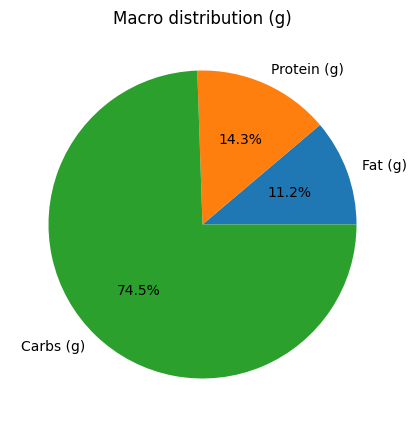

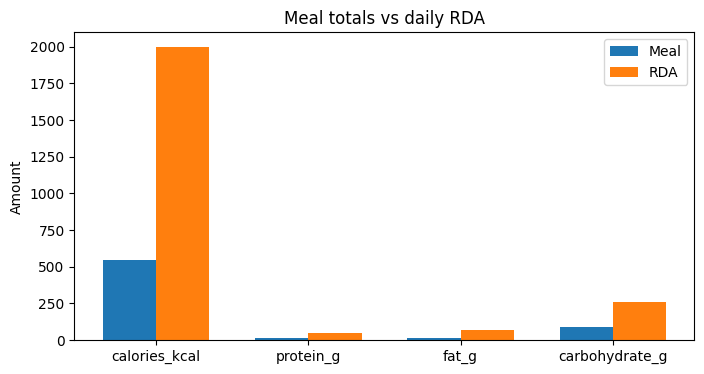

In [61]:
# CELL 10: Visualize meal macros and RDA coverage for the example meal (uses matplotlib)
# Make sure matplotlib inline in Jupyter (usually default)
%matplotlib inline

totals = meal_profile['totals']
# macro pie: fat, protein, carbohydrate in grams (ignore NaN)
macro_vals = [totals.get('fat_g', np.nan), totals.get('protein_g', np.nan), totals.get('carbohydrate_g', np.nan)]
macro_labels = ['Fat (g)', 'Protein (g)', 'Carbs (g)']
# filter out NaN
vals = [v if not (isinstance(v,float) and np.isnan(v)) else 0.0 for v in macro_vals]
if sum(vals) > 0:
    plt.figure(figsize=(5,5))
    plt.pie(vals, labels=macro_labels, autopct='%1.1f%%')
    plt.title("Macro distribution (g)")
    plt.show()
else:
    print("Macros not available to plot.")

# Bar chart: calories, protein, fat, carbs vs RDA
nut_keys = ['calories_kcal','protein_g','fat_g','carbohydrate_g']
vals = [totals.get(k, np.nan) for k in nut_keys]
rda_vals = [RDA_DEFAULT.get(k, np.nan) for k in nut_keys]

x = np.arange(len(nut_keys))
width = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - width/2, [0 if pd.isna(v) else v for v in vals], width)
plt.bar(x + width/2, rda_vals, width)
plt.xticks(x, nut_keys)
plt.ylabel("Amount")
plt.title("Meal totals vs daily RDA")
plt.legend(['Meal', 'RDA'])
plt.show()


In [62]:
# CELL 11: If some rows in your dataset have 'calories_kcal' per dish, compare aggregator estimates for similar dishes.
# This is a crude check: for parsed dish names that map exactly to a single mm_id, compare aggregator calories vs df calories_kcal.
def evaluate_on_dataset_sample(n_samples=100):
    rows = []
    sample = df.sample(min(n_samples, len(df)), random_state=1)
    for _, row in sample.iterrows():
        # try to parse dish_name or ingredients into parsed_parts using previously defined splitting+parsing
        text = None
        if isinstance(row.get('dish_name'), str) and row['dish_name'].strip():
            text = row['dish_name']
        elif isinstance(row.get('ingredients'), str) and row['ingredients'].strip():
            text = row['ingredients']
        else:
            continue
        parsed = []
        for part in split_to_ingredients(str(text)):
            qty, unit = parse_quantity_unit(part)
            grams = qty_unit_to_grams(qty, unit)
            clean = QTY_REGEX.sub('', part).strip()
            parsed.append({"original": part, "clean": clean, "approx_grams": grams})
        meal_prof = aggregate_meal_from_parsed(parsed)
        est_cal = meal_prof['totals'].get('calories_kcal', float('nan'))
        gt = pd.to_numeric(row.get('calories_kcal', np.nan), errors='coerce')
        if not pd.isna(est_cal) and not pd.isna(gt):
            rows.append((est_cal, gt))
    if not rows:
        print("No comparable rows found for evaluation.")
        return
    arr = np.array(rows)
    mae = np.mean(np.abs(arr[:,0] - arr[:,1]))
    print(f"Evaluation on {len(rows)} rows: MAE (calories) = {mae:.2f} kcal")
    return mae

# Run quick evaluation (may be noisy because parsing and portion assumptions are heuristic)
mae = evaluate_on_dataset_sample(n_samples=200)
print("MAE calories (rough):", mae)


Evaluation on 200 rows: MAE (calories) = 420.75 kcal
MAE calories (rough): 420.745


In [63]:
# CELL 12: Save functions/important artifacts for Streamlit (simple approach: save df and candidate_map paths + embed model name)
config = {
    "data_csv": CSV_FILE,
    "artifact_dir": ART_DIR,
    "embedding_model": EMBEDDING_MODEL if 'EMBEDDING_MODEL' in globals() else "all-MiniLM-L6-v2",
    "faiss_index": faiss_index_path if 'faiss_index_path' in globals() else os.path.join(ART_DIR, "mm_candidates_faiss.index"),
    "candidate_map": candidate_map_path if os.path.exists(candidate_map_path) else None
}
with open(os.path.join(ART_DIR,"nutrition_aggregator_config.json"), "w", encoding="utf8") as f:
    json.dump(config, f, indent=2)
print("Saved aggregator config to:", os.path.join(ART_DIR,"nutrition_aggregator_config.json"))


Saved aggregator config to: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts\nutrition_aggregator_config.json


# Summary — Nutrition Aggregator
- We implemented ingredient→nutrient conversion using aggregated per-100g profiles from the MM dataset.
- Per-ingredient amounts are computed using `approx_grams` from the parser.
- The aggregator returns ingredient breakdown, meal totals, RDA coverage, and daily aggregation utilities.
- Next steps: 
  1. Improve representative mm_id selection criteria (use cooking_method/dish context). 
  2. Replace heuristics (cup→grams) with an ingredient-specific density lookup for better accuracy. 
  3. Build UI components in Streamlit to call `parse_and_map_meal_mm()` then `aggregate_meal_from_parsed()` on user input and show results/plots.


# Feature 3 — Interpretability Layer
**Goal:** Convert numeric meal nutrient outputs into clear, human-friendly explanations: summary sentence, risk flags, nutrient diversity score, prioritized suggestions and healthy swaps.


In [64]:
# CELL 2: Imports and path configuration
import os, json, math
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# Paths (adjust to match your project)
DATA_DIR = r"C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data"
ART_DIR = os.path.join(DATA_DIR, "artifacts")
MEAL_EST_PATH = os.path.join(ART_DIR, "latest_meal_estimates.csv")  # if you saved earlier
CONFIG_PATH = os.path.join(ART_DIR, "ingredient_parser_mm_config.json")

print("DATA_DIR:", DATA_DIR)
print("ART_DIR:", ART_DIR)
print("MEAL_EST_PATH:", MEAL_EST_PATH)


DATA_DIR: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data
ART_DIR: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts
MEAL_EST_PATH: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts\latest_meal_estimates.csv


In [65]:
# CELL 3: Load recently computed meal estimates (if saved) or compute an example via previous pipeline
if os.path.exists(MEAL_EST_PATH):
    final_df = pd.read_csv(MEAL_EST_PATH)
    print("Loaded meal estimates from:", MEAL_EST_PATH)
    display(final_df)
else:
    # Fallback: if no saved file, we try to reconstruct meal_profile from previous cells (assumes kernel still has them)
    try:
        final_df = final_df.copy()  # from previous Feature 2 example (if still in memory)
        print("Using in-memory final_df from previous step.")
    except Exception:
        raise FileNotFoundError("No meal estimates CSV found and no in-memory final_df present. Run Feature 2 cells first and save meal estimates.")


Using in-memory final_df from previous step.


In [66]:
# CELL 4: Define RDA defaults and thresholds for risk flags and suggestions
RDA_DEFAULT = {
    "calories_kcal": 2000.0,
    "protein_g": 50.0,
    "fat_g": 70.0,
    "carbohydrate_g": 260.0,
    # Add micronutrients if available (sodium_mg, fiber_g, sugar_g) — here's placeholders
    "sodium_mg": 2300.0,
    "fiber_g": 25.0,
    "sugar_g": 50.0
}

# Thresholds for flags (proportion of daily RDA per meal)
THRESHOLDS = {
    "high_calories_pct": 35.0,   # meal > 35% of daily calories -> "high calorie meal"
    "high_sodium_mg": 800.0,     # absolute mg in a meal (example)
    "high_sugar_g": 30.0,        # grams in a meal
    "high_fat_g": 25.0,          # grams in a meal (example)
    "low_protein_g": 10.0        # if protein < 10g flag low protein (example)
}

# small helpers
def pct_of_rda(value, rda_key):
    rda = RDA_DEFAULT.get(rda_key)
    if rda is None or (isinstance(value,float) and math.isnan(value)):
        return float('nan')
    return (value / rda) * 100.0

def safe(val):
    return None if (val is None or (isinstance(val,float) and np.isnan(val))) else float(val)


In [67]:
# CELL 5: Compute a nutrient diversity / balance score for a meal
# Idea: score combines macro balance (calories from carbs/pro/fat close to target),
# variety (count of distinct food groups present — approximated by ingredient variety),
# and presence of fiber/veg (if available).

def macro_calorie_breakdown(totals):
    # calories from macros (approx): protein 4 kcal/g, carbs 4 kcal/g, fat 9 kcal/g
    protein = safe(totals.get('protein_g', float('nan')))
    carbs = safe(totals.get('carbohydrate_g', float('nan')))
    fat = safe(totals.get('fat_g', float('nan')))
    c_pro = protein*4 if protein is not None else 0.0
    c_carb = carbs*4 if carbs is not None else 0.0
    c_fat = fat*9 if fat is not None else 0.0
    total = c_pro + c_carb + c_fat
    if total <= 0:
        return {"protein_kcal": c_pro, "carb_kcal": c_carb, "fat_kcal": c_fat, "pct_protein": None, "pct_carbs": None, "pct_fat": None}
    return {
        "protein_kcal": c_pro, "carb_kcal": c_carb, "fat_kcal": c_fat,
        "pct_protein": (c_pro/total)*100.0,
        "pct_carbs": (c_carb/total)*100.0,
        "pct_fat": (c_fat/total)*100.0
    }

def nutrient_diversity_score(totals, ingredient_texts=None):
    # Macro balance target (percentage of calories): carbs 50%, fat 30%, protein 20% (example)
    target = {"pct_carbs":50.0, "pct_fat":30.0, "pct_protein":20.0}
    breakdown = macro_calorie_breakdown(totals)
    if breakdown['pct_protein'] is None:
        macro_score = 0.0
    else:
        # score = 100 - sum absolute deviations from target (clipped)
        dev = abs(breakdown['pct_protein'] - target['pct_protein']) + abs(breakdown['pct_carbs'] - target['pct_carbs']) + abs(breakdown['pct_fat'] - target['pct_fat'])
        macro_score = max(0.0, 100.0 - dev)  # higher is better
    # variety score: number of distinct ingredient tokens (approx)
    var_score = 0.0
    if ingredient_texts:
        # simple split on comma/space and count distinct words excluding stop words
        stops = set(["and","with","of","the","a","an","in","on","cup","cups","tbsp","tsp"])
        words = set()
        for t in ingredient_texts:
            for w in str(t).lower().split():
                w = w.strip(".,()[]'\"")
                if w and w not in stops and len(w)>2:
                    words.add(w)
        var_score = min(100.0, len(words) * 5.0)  # each distinct word gives +5 up to 100
    # fiber / veggies boost (if fiber_g present)
    fiber = safe(totals.get('fiber_g', float('nan')))
    fiber_boost = 10.0 if (fiber is not None and fiber >= 5.0) else 0.0
    # combine scores (weights can be tuned)
    final_score = 0.6*macro_score + 0.3*var_score + 0.1*fiber_boost
    # normalize to 0-100
    final_score = max(0.0, min(100.0, final_score))
    return {"macro_score": macro_score, "var_score": var_score, "fiber_boost": fiber_boost, "final_score": final_score, "breakdown": breakdown}


In [68]:
# CELL 6: Produce human-friendly explanations, risk flags, and prioritized suggestions
# This is rule-based and transparent; you can later augment with LLM for rich wording.

HEALTHY_SWAP_EXAMPLES = {
    "fries": "roasted sweet potato",
    "soda": "sparkling water with lemon",
    "fried": "baked or grilled",
    "butter": "olive oil (use sparingly)",
    "white rice": "brown rice or quinoa",
    "sugar": "fresh fruit or stevia"
}

def interpret_meal(totals, ingredient_texts=None):
    """
    Input: totals (Series/dict of meal-level nutrients), ingredient_texts: list of original ingredient strings
    Returns: dict with summary, flags, suggestions, nutrient_diversity
    """
    tot = {k: safe(v) for k,v in totals.items()}
    # Summary sentence
    cal = tot.get('calories_kcal', float('nan'))
    prot = tot.get('protein_g', float('nan'))
    fat = tot.get('fat_g', float('nan'))
    carbs = tot.get('carbohydrate_g', float('nan'))
    summary = []
    if not pd.isna(cal):
        summary.append(f"Estimated {int(round(cal))} kcal")
    if not pd.isna(prot):
        summary.append(f"{int(round(prot))} g protein")
    if not pd.isna(fat):
        summary.append(f"{int(round(fat))} g fat")
    if not pd.isna(carbs):
        summary.append(f"{int(round(carbs))} g carbs")
    summary_text = "; ".join(summary) + "."

    # Flags
    flags = []
    # high calories relative to RDA
    if not pd.isna(cal):
        pct = pct_of_rda(cal, "calories_kcal")
        if pct >= THRESHOLDS["high_calories_pct"]:
            flags.append({"type":"high_calories", "message": f"This meal provides {pct:.0f}% of daily calories (high)."})
    # high fat
    if not pd.isna(fat) and fat >= THRESHOLDS["high_fat_g"]:
        flags.append({"type":"high_fat", "message": f"High fat: {fat:.1f} g in this meal."})
    # low protein
    if (prot is None) or (not pd.isna(prot) and prot <= THRESHOLDS["low_protein_g"]):
        flags.append({"type":"low_protein", "message": f"Protein is low ({prot if not pd.isna(prot) else 'N/A'} g). Consider adding a protein source."})
    # sodium / sugar flags if present in data (use sodium_mg, sugar_g if available)
    if 'sodium_mg' in totals and not pd.isna(totals.get('sodium_mg')):
        if totals.get('sodium_mg') >= THRESHOLDS['high_sodium_mg']:
            flags.append({"type":"high_sodium", "message": f"High sodium (~{int(totals['sodium_mg'])} mg). Consider lower-sodium options."})
    if 'sugar_g' in totals and not pd.isna(totals.get('sugar_g')):
        if totals.get('sugar_g') >= THRESHOLDS['high_sugar_g']:
            flags.append({"type":"high_sugar", "message": f"High sugar: {int(totals['sugar_g'])} g."})

    # Suggestions: rule-based replacements — search ingredient_texts for keys
    suggestions = []
    if ingredient_texts:
        joined = " ".join([str(x).lower() for x in ingredient_texts])
        for key, swap in HEALTHY_SWAP_EXAMPLES.items():
            if key in joined:
                suggestions.append({"from": key, "to": swap, "reason": f"Swap {key} for {swap} to reduce unhealthy fats/sugars."})

    # nutrient diversity
    ndscore = nutrient_diversity_score(totals, ingredient_texts=ingredient_texts)

    # small actionable tips based on flags
    actionable = []
    for f in flags:
        if f['type'] == 'high_calories':
            actionable.append("Consider halving portion size or adding non-starchy vegetables to increase volume with fewer calories.")
        if f['type'] == 'high_fat':
            actionable.append("Use lean protein or cook with less oil; replace deep-frying with roasting.")
        if f['type'] == 'low_protein':
            actionable.append("Add a source of lean protein (eggs, Greek yogurt, tofu, chicken breast).")
        if f['type'] == 'high_sodium':
            actionable.append("Reduce added salt, choose low-sodium sauces, or rinse canned items.")

    result = {
        "summary": summary_text,
        "flags": flags,
        "suggestions": suggestions,
        "actionable_tips": actionable,
        "nutrient_diversity": ndscore
    }
    return result


In [69]:
# CELL 7: Run the interpreter on the example meal totals (uses meal_profile from Feature 2 if present)
# If you have 'meal_profile' from earlier, use that; else use final_df aggregated sums.

if 'meal_profile' in globals():
    totals = meal_profile['totals']
    ingredient_texts = list(meal_profile['ingredients_df']['original'].astype(str))
else:
    # construct totals from final_df if present
    if 'final_df' in globals():
        # final_df contains per-ingredient scaled columns; we compute totals
        dfcopy = final_df.copy()
        # identify numeric nutrient columns
        numeric_cols = [c for c in dfcopy.columns if c not in ['original','clean','rep_mmid']]
        totals = dfcopy[numeric_cols].apply(pd.to_numeric, errors='coerce').sum(skipna=True)
        ingredient_texts = list(dfcopy['original'].astype(str))
    else:
        raise RuntimeError("No meal_profile or final_df found in memory. Run Feature 2 first.")

interpretation = interpret_meal(totals, ingredient_texts=ingredient_texts)
print("Summary:")
print(interpretation['summary'])
print("\nFlags:")
for f in interpretation['flags']:
    print("-", f['message'])
print("\nSuggestions (swaps):")
for s in interpretation['suggestions']:
    print("-", s['from'], "→", s['to'], "|", s['reason'])
print("\nActionable tips:")
for t in interpretation['actionable_tips']:
    print("-", t)
print("\nNutrient diversity score (0-100):", interpretation['nutrient_diversity']['final_score'])
print("Macro breakdown (pct):", interpretation['nutrient_diversity']['breakdown']['pct_protein'],
      interpretation['nutrient_diversity']['breakdown']['pct_carbs'],
      interpretation['nutrient_diversity']['breakdown']['pct_fat'])


Summary:
Estimated 546 kcal; 18 g protein; 14 g fat; 91 g carbs.

Flags:

Suggestions (swaps):

Actionable tips:

Nutrient diversity score (0-100): 49.11666267364325
Macro breakdown (pct): 12.586539117328503 65.31944777196397 22.094013110707543


In [70]:
# CELL 8: Save the interpretation result for the meal to an artifacts folder (for UI / demo)
OUT_PATH = os.path.join(ART_DIR, "last_meal_interpretation.json")
with open(OUT_PATH, "w", encoding="utf8") as f:
    json.dump(interpretation, f, indent=2, default=lambda x: (None if (isinstance(x,float) and np.isnan(x)) else x))
print("Saved interpretation to:", OUT_PATH)


Saved interpretation to: C:\Users\Aaditya\Desktop\NutriSage_Local\preprocessed_data\artifacts\last_meal_interpretation.json


In [71]:
# CELL 9: Quick sanity checks on the interpreter behavior with edge cases
tests = [
    {"totals": {"calories_kcal": 900, "protein_g": 10, "fat_g": 60, "carbohydrate_g": 80}, "ingredients": ["fries", "burger"]},
    {"totals": {"calories_kcal": 350, "protein_g": 25, "fat_g": 10, "carbohydrate_g": 40}, "ingredients": ["grilled salmon", "salad"]},
    {"totals": {"calories_kcal": None, "protein_g": None, "fat_g": None, "carbohydrate_g": None}, "ingredients": ["unknown"]}
]

for t in tests:
    print("\nTest totals:", t['totals'])
    out = interpret_meal(t['totals'], t['ingredients'])
    print("Summary:", out['summary'])
    print("Flags:", [f['type'] for f in out['flags']])
    print("Suggestions:", out['suggestions'])
    print("Diversity score:", out['nutrient_diversity']['final_score'])



Test totals: {'calories_kcal': 900, 'protein_g': 10, 'fat_g': 60, 'carbohydrate_g': 80}
Summary: Estimated 900 kcal; 10 g protein; 60 g fat; 80 g carbs.
Flags: ['high_calories', 'high_fat', 'low_protein']
Suggestions: [{'from': 'fries', 'to': 'roasted sweet potato', 'reason': 'Swap fries for roasted sweet potato to reduce unhealthy fats/sugars.'}]
Diversity score: 27.0

Test totals: {'calories_kcal': 350, 'protein_g': 25, 'fat_g': 10, 'carbohydrate_g': 40}
Summary: Estimated 350 kcal; 25 g protein; 10 g fat; 40 g carbs.
Flags: []
Suggestions: []
Diversity score: 54.214285714285715

Test totals: {'calories_kcal': None, 'protein_g': None, 'fat_g': None, 'carbohydrate_g': None}
Summary: .
Flags: ['low_protein']
Suggestions: []
Diversity score: 1.5


In [6]:
# ================================================================
# 0. Setup
# ================================================================



# ================================================================
# 0. Setup sys.path so Python can find your src folder
# ================================================================
import sys
import os

project_root = r"C:/Users/Aaditya/Desktop/smart-nutrition-assistant"
sys.path.append(os.path.join(project_root, "src"))

# ================================================================
# 1. Now import WITHOUT src.
# ================================================================
from nutrition_mm import sanitize_df    # <-- correct import

import pandas as pd

# ================================================================
# 2. Load data
# ================================================================
df = pd.read_csv(r"C:/Users/Aaditya/Desktop/smart-nutrition-assistant/data/MM_Food_Cleaned_Final.csv")

# ================================================================
# 3. Sanitize
# ================================================================
df = sanitize_df(df, verbose=True)
df.head()




Sanitization complete. Non-null counts for per-100g columns:
  calories_kcal_per_100g: 10887 / 10996
  fat_g_per_100g: 10887 / 10996
  protein_g_per_100g: 10887 / 10996
  carbohydrate_g_per_100g: 10887 / 10996


,dish_name,image_filepath,submission_date,food_type,food_type.1,cooking_method,ingredients,total_grams,is_duplicate_image,calories_kcal,fat_g,protein_g,carbohydrate_g,calories_kcal_per_100g,fat_g_per_100g,protein_g_per_100g,carbohydrate_g_per_100g
0,spicy crab,preprocessed_data\images_processed\0a0c19eb67a...,2025-07-05,Restaurant food,restaurant food,stir-fried,"['crab', 'sauce', 'spices', 'vegetables']",450.0,False,500,20.0,40.0,10.0,111.111111,4.444444,8.888889,2.222222
1,steamed snails,preprocessed_data\images_processed\066b7ba6197...,2025-07-01,Homemade food,homemade food,steamed,"['dipping sauce', 'garlic', 'herbs', 'snails']",350.0,False,200,5.0,30.0,10.0,57.142857,1.428571,8.571429,2.857143
2,chicken stirfry,preprocessed_data\images_processed\fecd381a783...,2025-07-18,Homemade food,homemade food,stir-frying,"['bell peppers', 'chicken', 'onions', 'soy sau...",450.0,False,450,20.0,30.0,25.0,100.000000,4.444444,6.666667,5.555556
3,grilled salmon,preprocessed_data\images_processed\01e3ca00199...,2025-07-19,Restaurant food,restaurant food,Grilling,"['butter sauce', 'herbs', 'salmon']",250.0,False,350,20.0,30.0,5.0,140.000000,8.000000,12.000000,2.000000
4,braised pork belly,preprocessed_data\images_processed\34256ac8f85...,2025-07-04,Restaurant food,restaurant food,Braised,"['Green Onion', 'Pork Belly', 'Rice', 'Soy Sau...",350.0,False,600,30.0,25.0,50.0,171.428571,8.571429,7.142857,14.285714


In [8]:
# Cell 1: setup sys.path so we can import from src/
import sys, os

# CHANGE this if your project root is elsewhere
project_root = r"C:/Users/Aaditya/Desktop/smart-nutrition-assistant"

# Add src dir to path so we can import nutrition_mm directly
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("project_root:", project_root)
print("src_path added to sys.path:", src_path)


project_root: C:/Users/Aaditya/Desktop/smart-nutrition-assistant
src_path added to sys.path: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\src


In [9]:
# Cell 2: imports and paths
import os
import pandas as pd
import numpy as np

# Set data and models paths (relative to project_root)
DATA_CSV = os.path.join(project_root, "data", "MM_Food_Cleaned_Final.csv")
MODELS_DIR = os.path.join(project_root, "models")

# ensure models dir exists
os.makedirs(MODELS_DIR, exist_ok=True)

print("DATA_CSV:", DATA_CSV)
print("MODELS_DIR:", MODELS_DIR)


DATA_CSV: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\data\MM_Food_Cleaned_Final.csv
MODELS_DIR: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models


In [10]:
# Cell 3: import functions from your module
# NOTE: after adding src_path to sys.path above, import without "src."
from nutrition_mm import sanitize_df, train_rf_for_nutrient, load_rf_model, predict_nutrient_with_rf

print("Imported functions from nutrition_mm:")
print(" - sanitize_df:", callable(sanitize_df))
print(" - train_rf_for_nutrient:", callable(train_rf_for_nutrient))
print(" - load_rf_model:", callable(load_rf_model))
print(" - predict_nutrient_with_rf:", callable(predict_nutrient_with_rf))


Imported functions from nutrition_mm:
 - sanitize_df: True
 - train_rf_for_nutrient: True
 - load_rf_model: True
 - predict_nutrient_with_rf: True


In [11]:
# Cell 4: load data and sanitize
df = pd.read_csv(DATA_CSV)
print("Raw df shape:", df.shape)

# sanitize_df may print summary when verbose=True
df = sanitize_df(df, verbose=True)
print("Sanitized df shape:", df.shape)

# quick peek
df.head(3)


Raw df shape: (10996, 17)
Sanitization complete. Non-null counts for per-100g columns:
  calories_kcal_per_100g: 10887 / 10996
  fat_g_per_100g: 10887 / 10996
  protein_g_per_100g: 10887 / 10996
  carbohydrate_g_per_100g: 10887 / 10996
Sanitized df shape: (10996, 17)


,dish_name,image_filepath,submission_date,food_type,food_type.1,cooking_method,ingredients,total_grams,is_duplicate_image,calories_kcal,fat_g,protein_g,carbohydrate_g,calories_kcal_per_100g,fat_g_per_100g,protein_g_per_100g,carbohydrate_g_per_100g
0,spicy crab,preprocessed_data\images_processed\0a0c19eb67a...,2025-07-05,Restaurant food,restaurant food,stir-fried,"['crab', 'sauce', 'spices', 'vegetables']",450.0,False,500,20.0,40.0,10.0,111.111111,4.444444,8.888889,2.222222
1,steamed snails,preprocessed_data\images_processed\066b7ba6197...,2025-07-01,Homemade food,homemade food,steamed,"['dipping sauce', 'garlic', 'herbs', 'snails']",350.0,False,200,5.0,30.0,10.0,57.142857,1.428571,8.571429,2.857143
2,chicken stirfry,preprocessed_data\images_processed\fecd381a783...,2025-07-18,Homemade food,homemade food,stir-frying,"['bell peppers', 'chicken', 'onions', 'soy sau...",450.0,False,450,20.0,30.0,25.0,100.000000,4.444444,6.666667,5.555556


In [12]:
# Cell 5: check available rows for each target
targets = [
    "calories_kcal_per_100g",
    "protein_g_per_100g",
    "fat_g_per_100g",
    "carbohydrate_g_per_100g"
]

for t in targets:
    if t in df.columns:
        n = df[t].notna().sum()
        print(f"{t}: {n} non-null rows")
    else:
        print(f"{t}: column NOT PRESENT in df")


calories_kcal_per_100g: 10887 non-null rows
protein_g_per_100g: 10887 non-null rows
fat_g_per_100g: 10887 non-null rows
carbohydrate_g_per_100g: 10887 non-null rows


In [13]:
# Cell 6: final correct features for RF training

numeric_features = []   # no useful numeric features
categorical_features = ["food_type", "cooking_method"]

# Keep only those that exist in df
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Using numeric features:", numeric_features)
print("Using categorical features:", categorical_features)


Using numeric features: []
Using categorical features: ['food_type', 'cooking_method']


In [14]:
# Cell 7: train calories RF
target = "calories_kcal_per_100g"
if target in df.columns and df[target].notna().sum() >= 50:
    print("Training RF for", target)
    model_path = train_rf_for_nutrient(
        df=df,
        target_col=target,
        feature_cols=numeric_features,
        text_feature_col=None,   # set if you precomputed embeddings
        cat_cols=categorical_features,
        save_path=MODELS_DIR,
        model_name=f"rf_{target}.pkl",
        n_estimators=200,
        random_state=42,
        cv_folds=5
    )
    print("Saved model at:", model_path)
else:
    print(f"Skipping {target} — not enough data or column missing.")


Training RF for calories_kcal_per_100g
CV MAE for calories_kcal_per_100g: 31.831
Saved RF model to: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_calories_kcal_per_100g.pkl
Saved model at: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_calories_kcal_per_100g.pkl


In [15]:
# Cell 8: train protein RF
target = "protein_g_per_100g"
if target in df.columns and df[target].notna().sum() >= 50:
    print("Training RF for", target)
    model_path = train_rf_for_nutrient(
        df=df,
        target_col=target,
        feature_cols=numeric_features,
        text_feature_col=None,
        cat_cols=categorical_features,
        save_path=MODELS_DIR,
        model_name=f"rf_{target}.pkl",
        n_estimators=200,
        random_state=42,
        cv_folds=5
    )
    print("Saved model at:", model_path)
else:
    print(f"Skipping {target} — not enough data or column missing.")


Training RF for protein_g_per_100g
CV MAE for protein_g_per_100g: 2.014
Saved RF model to: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_protein_g_per_100g.pkl
Saved model at: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_protein_g_per_100g.pkl


In [16]:
# Cell 9: train fat RF
target = "fat_g_per_100g"
if target in df.columns and df[target].notna().sum() >= 50:
    print("Training RF for", target)
    model_path = train_rf_for_nutrient(
        df=df,
        target_col=target,
        feature_cols=numeric_features,
        text_feature_col=None,
        cat_cols=categorical_features,
        save_path=MODELS_DIR,
        model_name=f"rf_{target}.pkl",
        n_estimators=200,
        random_state=42,
        cv_folds=5
    )
    print("Saved model at:", model_path)
else:
    print(f"Skipping {target} — not enough data or column missing.")


Training RF for fat_g_per_100g
CV MAE for fat_g_per_100g: 1.856
Saved RF model to: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_fat_g_per_100g.pkl
Saved model at: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_fat_g_per_100g.pkl


In [17]:
# Cell 10: train carbohydrate RF
target = "carbohydrate_g_per_100g"
if target in df.columns and df[target].notna().sum() >= 50:
    print("Training RF for", target)
    model_path = train_rf_for_nutrient(
        df=df,
        target_col=target,
        feature_cols=numeric_features,
        text_feature_col=None,
        cat_cols=categorical_features,
        save_path=MODELS_DIR,
        model_name=f"rf_{target}.pkl",
        n_estimators=200,
        random_state=42,
        cv_folds=5
    )
    print("Saved model at:", model_path)
else:
    print(f"Skipping {target} — not enough data or column missing.")


Training RF for carbohydrate_g_per_100g
CV MAE for carbohydrate_g_per_100g: 5.400
Saved RF model to: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_carbohydrate_g_per_100g.pkl
Saved model at: C:/Users/Aaditya/Desktop/smart-nutrition-assistant\models\rf_carbohydrate_g_per_100g.pkl


In [18]:
# Cell 11: verify saved models
print("Files in models dir:")
print(os.listdir(MODELS_DIR))


Files in models dir:
['rf_calories_kcal_per_100g.pkl', 'rf_carbohydrate_g_per_100g.pkl', 'rf_fat_g_per_100g.pkl', 'rf_protein_g_per_100g.pkl']
